In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [58]:
!pip install quandl
!pip install yfinance

In [59]:
import yfinance as yf

data = yf.download("TATACONSUM.NS", start="2015-01-01", end="2024-12-31")
print(data.head())

[*********************100%***********************]  1 of 1 completed

Price              Close          High           Low          Open  \
Ticker     TATACONSUM.NS TATACONSUM.NS TATACONSUM.NS TATACONSUM.NS   
Date                                                                 
2015-01-01    132.653625    133.577890    132.345546    132.873688   
2015-01-02    134.238068    134.854240    132.521584    132.829663   
2015-01-05    134.634155    135.998545    133.489828    133.489828   
2015-01-06    130.408981    133.753933    129.396700    133.753933   
2015-01-07    130.673035    131.333222    128.516426    129.572723   

Price             Volume  
Ticker     TATACONSUM.NS  
Date                      
2015-01-01        535692  
2015-01-02       2043127  
2015-01-05       1873161  
2015-01-06       2390258  
2015-01-07       2770541  


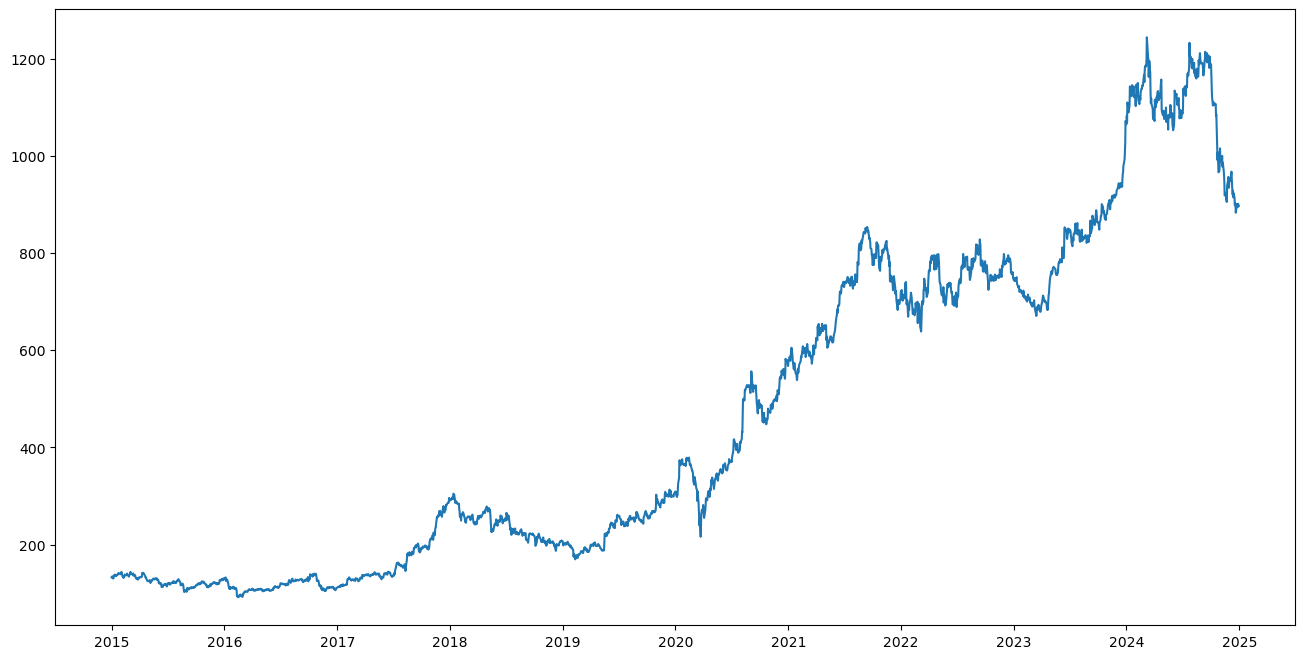

In [60]:
plt.figure(figsize=(16,8))
plt.plot(data['Close'],label='Closing Price')

In [61]:
data['Open - Close']=data['Open']-data['Close']
data['High - Low']=data['High']-data['Low']
data=data.dropna()

In [62]:
x=data[['Open - Close','High - Low']]
x.head()

Price,Open - Close,High - Low
Ticker,,
Date,,
2015-01-01,0.220062,1.232344
2015-01-02,-1.408405,2.332656
2015-01-05,-1.144327,2.508716
2015-01-06,3.344951,4.357233
2015-01-07,-1.100312,2.816796


In [63]:
Y=np.where(data['Close'].shift(-1)>data['Close'],1,-1)

In [64]:
Y

array([[ 1],
       [ 1],
       [-1],
       ...,
       [ 1],
       [-1],
       [-1]], shape=(2466, 1))

In [65]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, Y, test_size=0.25,random_state=10)

In [66]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn import neighbors

params={'n_neighbors':[2,3,4,5,6,7,8,9,10,11,12,13,14,15]}
knn=neighbors.KNeighborsClassifier()
model=GridSearchCV(knn,params,cv=5)

model.fit(X_train, np.ravel(y_train))

accuracy_train=accuracy_score(np.ravel(y_train), model.predict(X_train))
accuracy_test=accuracy_score(np.ravel(y_test), model.predict(X_test))

print('Training data accuracy:%.2f' %accuracy_train)
print('Testing data accuracy:%.2f' %accuracy_test)

Training data accuracy:0.61
Testing data accuracy:0.55


In [67]:
y=data['Close']
y

Ticker,TATACONSUM.NS
Date,
2015-01-01,132.653625
2015-01-02,134.238068
2015-01-05,134.634155
2015-01-06,130.408981
2015-01-07,130.673035
...,...
2024-12-23,896.108582
2024-12-24,900.625061
2024-12-26,894.321838


In [68]:
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor


y = data['Close']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    x,
    np.ravel(y),
    test_size=0.25,
    random_state=10,
)

params = {'n_neighbors': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]}
knn_reg = KNeighborsRegressor()
model_reg = GridSearchCV(knn_reg, params, cv=5)

model_reg.fit(X_train_reg, y_train_reg)
predictions = model_reg.predict(X_test_reg)

In [69]:
try:
    predictions
except NameError:
    print("Run the previous cell to compute predictions first.")
else:
    print(predictions)

[128.90466665 866.74771932 299.24638977 426.39513652 755.54180298
 133.23614095 432.37606506 697.37375081 205.94173126 128.22699331
 163.15458781 124.04630229 371.3234436  432.37606506 857.20340576
 195.74414012 773.4233134  127.9385081  140.97175039 337.57935994
 459.06392822 881.96199341 120.32359161 688.89109497 118.40067596
 565.35826721 489.04892782 718.01137594 164.07535451 637.32320455
 204.51908061 180.29396311 211.73468781 682.10114644 888.40832113
 941.21259359 267.39435933 128.74543864 726.14175822 134.97945404
 163.99915263 856.08068034 229.63904063 130.53756765 941.67666016
 230.01982676 687.10605062 126.17240041 151.37561493 225.3304067
 963.95202128 756.38641663 369.43038839 374.12863261 649.08988851
 720.30257975 711.64810791 116.95777893 637.95088298 775.07364705
 186.76400808 645.28605143 558.75788879 342.95061646 764.20342611
 492.80545756 785.79189046 120.94852753 955.7306071  125.83871765
 475.00173848 201.35198619 304.9018748  718.87619527 640.61833496
 158.185283

In [70]:
rms=np.sqrt(np.mean(np.power((np.array(y_test)-np.array(predictions)),2)))
rms

np.float64(526.9048669253986)

In [71]:
valid=pd.DataFrame({'Actual Value':y_test_reg,'Predicted Value':predictions})
valid.head(10)

,Actual Value,Predicted Value
0,136.412476,128.904667
1,1203.373291,866.747719
2,265.859253,299.246390
3,286.434998,426.395137
4,945.740723,755.541803
5,118.935547,133.236141
6,247.604858,432.376065
7,738.289124,697.373751
8,270.024994,205.941731
9,104.935257,128.226993
